# Welding Defect Dataset Report

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

### Set Dataset Path

In [6]:
dataset_path = "D:\Project\Welding Deductor\datasets2\datasets2"  
 
image_path = os.path.join(dataset_path, "D:\Project\Welding Deductor\datasets2\datasets2\images")

label_path = os.path.join(dataset_path, "D:\Project\Welding Deductor\datasets2\datasets2\labels")

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:5: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Sam\AppData\Local\Temp\ipykernel_28940\941500309.py:1: SyntaxWarning: invalid escape sequence '\P'
  dataset_path = "D:\Project\Welding Deductor\datasets2\datasets2"
C:\Users\Sam\AppData\Local\Temp\ipykernel_28940\941500309.py:3: SyntaxWarning: invalid escape sequence '\P'
  image_path = os.path.join(dataset_path, "D:\Project\Welding Deductor\datasets2\datasets2\images")
C:\Users\Sam\AppData\Local\Temp\ipykernel_28940\941500309.py:5: SyntaxWarning: invalid escape sequence '\P'
  label_path = os.path.join(dataset_path, "D:\Project\Welding Deductor\datasets2\datasets2\labels")


### Total Count of Image and Labels

In [7]:
image_files = sorted(os.listdir(image_path))
label_files = sorted(os.listdir(label_path))

print("Total Images:", len(image_files))
print("Total Labels:", len(label_files))

if len(image_files) == len(label_files):
    print("Dataset is properly matched (same number of images and labels).")
else:
    print("Warning: Images and Labels count mismatch!")

Total Images: 1512
Total Labels: 1512
Dataset is properly matched (same number of images and labels).


### Check Sample Image and Mask Properties

In [8]:
sample_img = cv2.imread(os.path.join(image_path, image_files[0]))
sample_mask = cv2.imread(os.path.join(label_path, label_files[0]), cv2.IMREAD_GRAYSCALE)

print("Sample Image Shape:", sample_img.shape)
print("Sample Mask Shape:", sample_mask.shape)

print("Unique values in Mask:", np.unique(sample_mask))

Sample Image Shape: (256, 512, 3)
Sample Mask Shape: (256, 512)
Unique values in Mask: [  0 255]


### Visualize Image and Mask

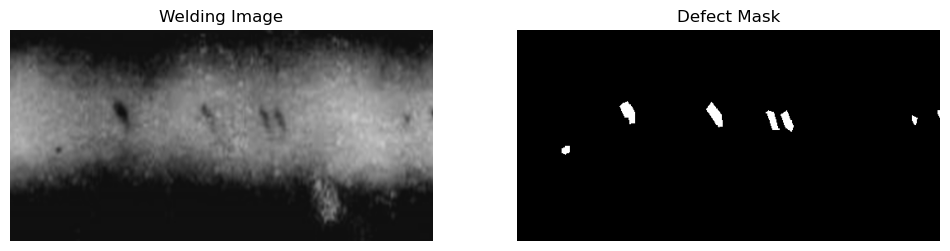

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
plt.title("Welding Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(sample_mask, cmap="gray")
plt.title("Defect Mask")
plt.axis("off")

plt.show()

### Overlay Mask on Image

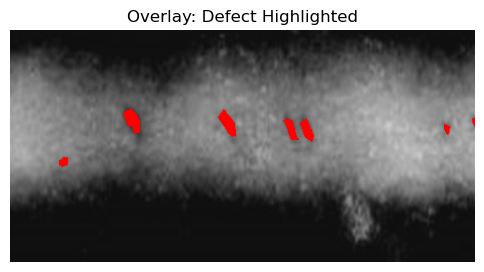

In [ ]:
overlay = sample_img.copy()
overlay[sample_mask == 255] = [0, 0, 255]  

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Overlay: Defect Highlighted")
plt.axis("off")
plt.show()

### Dataset Statistics 

In [11]:
image_shapes = []
defect_percentages = []

for img_file, mask_file in zip(image_files, label_files):
    img = cv2.imread(os.path.join(image_path, img_file))
    mask = cv2.imread(os.path.join(label_path, mask_file), cv2.IMREAD_GRAYSCALE)

    h, w, c = img.shape
    image_shapes.append((h, w))

    total_pixels = h * w
    defect_pixels = np.sum(mask == 255)

    defect_percentage = (defect_pixels / total_pixels) * 100
    defect_percentages.append(defect_percentage)

print("Average Defect Percentage:", np.mean(defect_percentages))
print("Maximum Defect Percentage:", np.max(defect_percentages))
print("Minimum Defect Percentage:", np.min(defect_percentages))

Average Defect Percentage: 1.8958091735839844
Maximum Defect Percentage: 6.998443603515625
Minimum Defect Percentage: 0.12359619140625


### Dataset Summary Table

In [12]:
df = pd.DataFrame({
    "Image_Name": image_files,
    "Label_Name": label_files,
    "Defect_Percentage": defect_percentages
})

df.head()

,Image_Name,Label_Name,Defect_Percentage
0,00000.png,00000.png,0.904083
1,00001.png,00001.png,1.847076
2,00002.png,00002.png,0.270844
3,00003.png,00003.png,1.562500
4,00004.png,00004.png,3.475189


### Defect Percentage Distribution

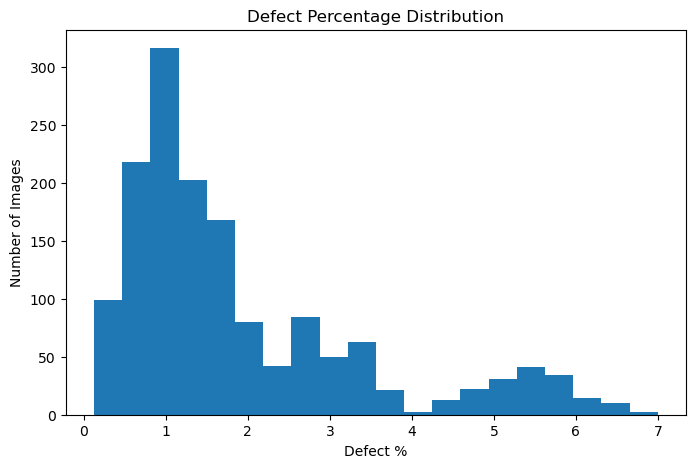

In [13]:
plt.figure(figsize=(8,5))
plt.hist(defect_percentages, bins=20)
plt.title("Defect Percentage Distribution")
plt.xlabel("Defect %")
plt.ylabel("Number of Images")
plt.show()

### Images with Highest Defects

In [14]:
df_sorted = df.sort_values(by="Defect_Percentage", ascending=False)
df_sorted.head(10)

,Image_Name,Label_Name,Defect_Percentage
300,00300.png,00300.png,6.998444
670,00670.png,00670.png,6.842041
1028,01028.png,01028.png,6.596375
1394,01394.png,01394.png,6.559753
1509,01509.png,01509.png,6.558990
52,00052.png,00052.png,6.511688
800,00800.png,00800.png,6.465149
269,00269.png,00269.png,6.449127
1298,01298.png,01298.png,6.403351
1226,01226.png,01226.png,6.371307


### Random Samples

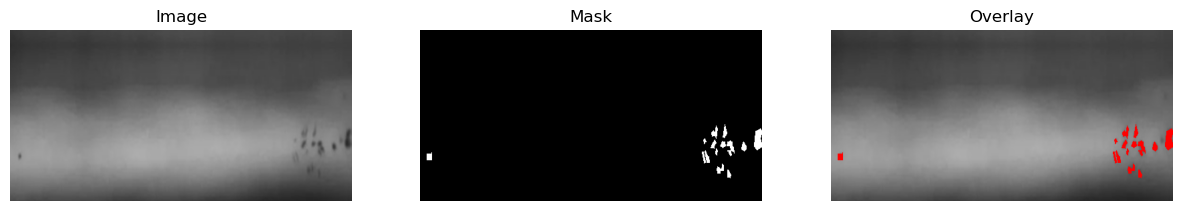

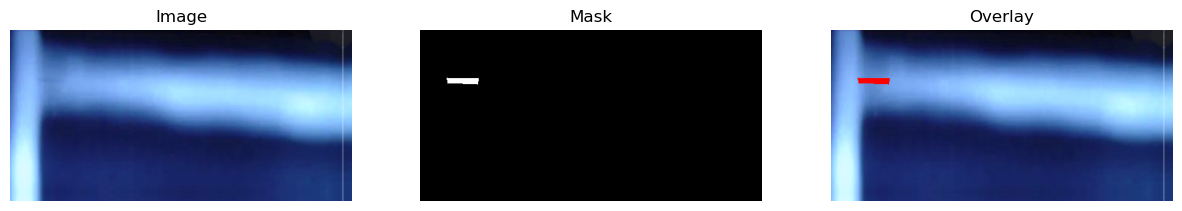

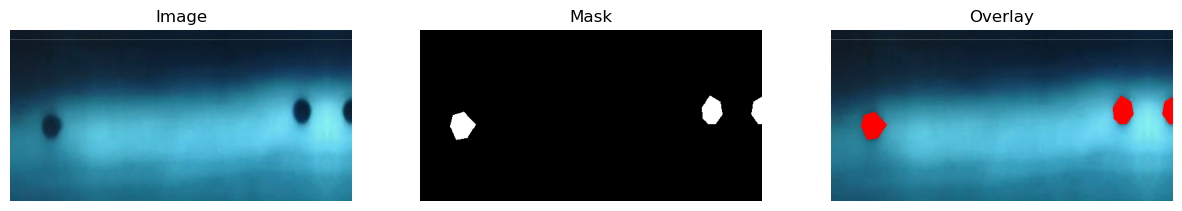

In [15]:
random_samples = random.sample(range(len(image_files)), 3)

for idx in random_samples:
    img = cv2.imread(os.path.join(image_path, image_files[idx]))
    mask = cv2.imread(os.path.join(label_path, label_files[idx]), cv2.IMREAD_GRAYSCALE)

    overlay = img.copy()
    overlay[mask == 255] = [0, 0, 255]

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

## Dataset Report 

This dataset is a **Welding Defect Detection dataset** designed for **binary semantic segmentation**, where the goal is to automatically identify and localize defective regions in welding seam images. The dataset contains welding seam images as input and corresponding defect mask images as ground truth labels. The mask images represent defects using pixel intensity values, where **0 indicates background (non-defect area)** and **255 indicates the defect region**.

This type of dataset is highly useful for building automated inspection systems in industrial applications, since manual weld defect inspection is time-consuming and may lead to human error. Similar to the reference research paper, welding defects can include surface irregularities such as **dents/depressions, scratches, slag, and bubbles**, which commonly occur in laser welding environments.

The dataset can be enhanced using **data augmentation techniques** such as rotation, translation, flipping, and brightness adjustment to improve model generalization and handle real-world challenges like noise, varying lighting conditions, and background interference. These preprocessing steps help increase dataset diversity and improve detection robustness.

Overall, this dataset is suitable for training deep learning models such as **U-Net, DeepLab, SegNet**, and also object detection-based approaches like **YOLOv8**, to build an accurate and efficient welding defect detection system for real-time industrial quality monitoring.